# Gradient Boosting

Gradient Boosting is an ensemble boosting technique where:

- small/base models are added sequentially
- each new model learns from errors of previous model
- finally all models combine to create a strong learner

---

# Gradient Boosting Regression

In Gradient Boosting Regression, the base models are usually:

- Decision Trees

(small regression trees)

---

# Step 1: First Base Model

The first base model is a simple Decision Tree.

Initially, prediction is usually:

## Mean of output values

Suppose target column is:

$$
y
$$

Then:

$$
\hat{y}_1
=
\text{mean}(y)
$$

This prediction is appended to the table.

---

# Step 2: Calculate Residuals

Now we calculate error:

$$
\text{Residual}
=
\text{Actual}
-
\text{Predicted}
$$

These residuals are called:

## Pseudo Residuals

They represent mistakes made by current model.

Residual column is appended to dataset.

---

# Step 3: Train Second Base Model

Now another Decision Tree is trained.

For this model:

- input = feature columns
- target = residual column

So the second model tries to predict errors made by first model.

Predictions of second model are appended to the table.

---

# Final Prediction (Two Models)

If only two base models are used:

$$
\text{Final Prediction}
=
\text{Output of Model 1}
+
\eta
\times
\text{Output of Model 2}
$$

where:

$$
\eta
$$

is learning rate.

Learning rate controls contribution of each tree.

---

# Step 4: Third Base Model

Now residuals of second stage are calculated:

$$
\text{Residual}_2
=
\text{Actual}
-
\text{Updated Prediction}
$$

These new residuals are appended to dataset.

Another Decision Tree is trained:

- input = feature columns
- output = residual 2

Again the model learns remaining errors.

---

# Final Prediction (Three Models)

$$
\text{Final Prediction}
=
\text{Output Model 1}
+
\eta \times \text{Output Model 2}
+
\eta \times \text{Output Model 3}
$$

---

# Important Idea

Each new model tries to correct mistakes left by previous models.

Thus predictions gradually improve stage-by-stage.

---

# Key Insight

- Trees are added sequentially
- Every tree learns residuals/errors
- Learning rate prevents overcorrection
- Final model is weighted sum of all trees

# Maths Behind Gradient Boosting Regression

---

# Additive Modelling

For non-linear data, we can use:

- Polynomial Regression

But high-degree polynomial regression suffers from:

## Runge’s Problem

Runge’s problem means high-degree polynomials create large oscillations near boundaries, leading to unstable predictions.

---

So instead of fitting one huge complex function, we use:

# Additive Modelling

Here, the final function is represented as sum of many small functions.

Example:

$$
f(x) = x + \sin(x)
$$

General form:

$$
F(x)
=
f_0(x)
+
f_1(x)
+
f_2(x)
+
\dots
$$

In Gradient Boosting:

- each small function is a Decision Tree

Thus many weak trees together create a strong predictive model.

---

# Core Idea of Gradient Boosting

At every stage:

- a new tree is added
- the tree learns errors/residuals of previous model
- model improves gradually

---

# Gradient Boosting Algorithm

## Input

Training dataset:

$$
\{(x_i, y_i)\}_{i=1}^{n}
$$

Loss function:

$$
L(y, F(x))
$$

Number of iterations:

$$
M
$$

---

# Step 1: Initialize Model

Initialize with constant prediction:

$$
f_0(x)
=
\arg\min_\gamma
\sum_{i=1}^{N}
L(y_i, \gamma)
$$

For squared loss, this usually becomes:

## Mean of target values

---

# Step 2: Iterative Boosting

For:

$$
m = 1 \text{ to } M
$$

repeat the following steps.

---

## (a) Compute Pseudo Residuals

For every sample:

$$
r_{im}
=
-
\left[
\frac{\partial L(y_i, f(x_i))}
{\partial f(x_i)}
\right]_{f=f_{m-1}}
$$

These residuals represent:

- direction of steepest descent
- errors remaining in current model

This is why it is called:

## Gradient Boosting

because we optimize using gradients.

---

## (b) Fit Regression Tree

Train a regression tree on residuals:

$$
r_{im}
$$

The tree creates terminal regions:

$$
R_{jm},
\quad
j = 1,2,\dots,J_m
$$

---

## (c) Compute Leaf Output Values

For each terminal region:

$$
\gamma_{jm}
=
\arg\min_\gamma
\sum_{x_i \in R_{jm}}
L
(
y_i,
f_{m-1}(x_i)+\gamma
)
$$

This computes best correction value for each leaf.

---

## (d) Update Model

Update final model:

$$
f_m(x)
=
f_{m-1}(x)
+
\sum_{j=1}^{J_m}
\gamma_{jm}
I(x \in R_{jm})
$$

where:

$$
I(x \in R_{jm})
$$

is indicator function:

- 1 if sample belongs to region
- 0 otherwise

---

# Final Intuition

Gradient Boosting works by:

1. making prediction
2. calculating gradients/residuals
3. fitting tree on residuals
4. adding correction to previous model

Thus model gradually moves toward minimum loss function.

In [31]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

In [3]:
import pandas as pd

In [4]:
df = pd.DataFrame()

In [5]:
df['X'] = X.reshape(100)
df['y'] = y

In [6]:
df

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


Text(0.5, 1.0, 'X vs y')

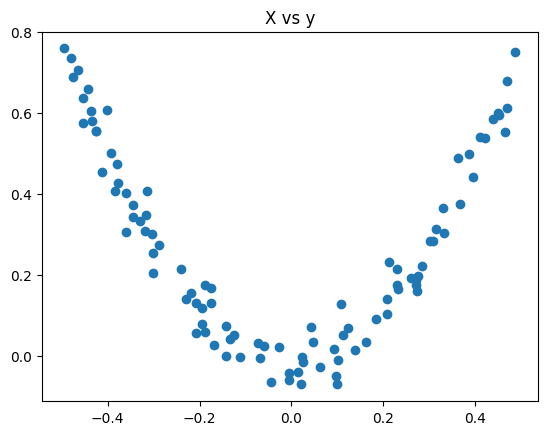

In [7]:
plt.scatter(df['X'], df['y'])
plt.title("X vs y")

In [8]:
df['pred1'] = df['y'].mean()

In [9]:
df

,X,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458
...,...,...,...
95,-0.006204,-0.040675,0.265458
96,0.022733,-0.002305,0.265458
97,-0.072459,0.032809,0.265458
98,-0.474581,0.689516,0.265458


In [12]:
df['res1'] = df['y'] - df['pred1']

In [13]:
df

,X,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528
...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133
96,0.022733,-0.002305,0.265458,-0.267763
97,-0.072459,0.032809,0.265458,-0.232650
98,-0.474581,0.689516,0.265458,0.424057


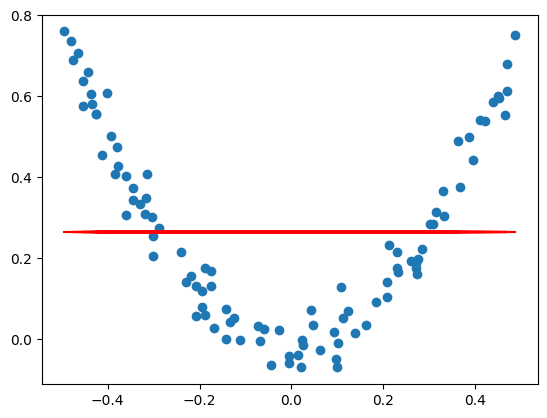

In [14]:
plt.scatter(df['X'],df['y'])
plt.plot(df['X'],df['pred1'],color='red')

In [15]:
from sklearn.tree import DecisionTreeRegressor

In [16]:
tree1 = DecisionTreeRegressor(max_leaf_nodes=8)

In [17]:
tree1.fit(df['X'].values.reshape(100,1),df['res1'].values)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

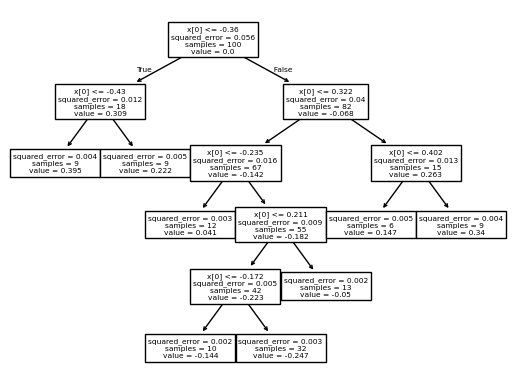

In [18]:
from sklearn.tree import plot_tree
plot_tree(tree1)
plt.show()

In [19]:
# generating X_test
X_test = np.linspace(-0.5, 0.5, 500)

In [20]:
y_pred = 0.265458 + tree1.predict(X_test.reshape(500, 1))

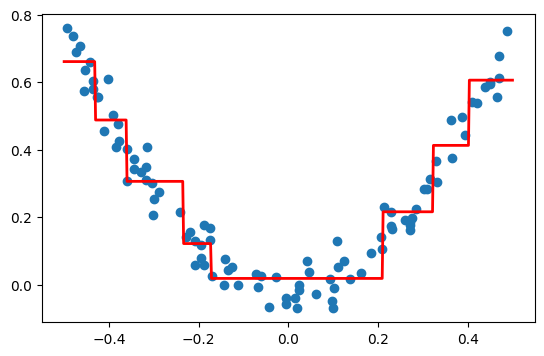

In [21]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth=2,color='red')
plt.scatter(df['X'],df['y'])

In [22]:
df['pred2'] = 0.265458 + tree1.predict(df['X'].values.reshape(100,1))

In [23]:
df

,X,y,pred1,res1,pred2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319
1,0.450714,0.594480,0.265458,0.329021,0.605884
2,0.231994,0.166052,0.265458,-0.099407,0.215784
3,0.098658,-0.070178,0.265458,-0.335636,0.018319
4,-0.343981,0.343986,0.265458,0.078528,0.305964
...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018319
96,0.022733,-0.002305,0.265458,-0.267763,0.018319
97,-0.072459,0.032809,0.265458,-0.232650,0.018319
98,-0.474581,0.689516,0.265458,0.424057,0.660912


In [24]:
df['res2'] = df['y'] - df['pred2']
df

,X,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319,0.033254
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732
3,0.098658,-0.070178,0.265458,-0.335636,0.018319,-0.088497
4,-0.343981,0.343986,0.265458,0.078528,0.305964,0.038022
...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018319,-0.058994
96,0.022733,-0.002305,0.265458,-0.267763,0.018319,-0.020624
97,-0.072459,0.032809,0.265458,-0.232650,0.018319,0.014489
98,-0.474581,0.689516,0.265458,0.424057,0.660912,0.028604


In [25]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)

In [26]:
tree2.fit(df['X'].values.reshape(100,1),df['res2'].values)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [27]:
y_pred = 0.265458 + sum(regressor.predict(X_test.reshape(-1, 1)) for regressor in [tree1,tree2])

Text(0.5, 1.0, 'X vs y')

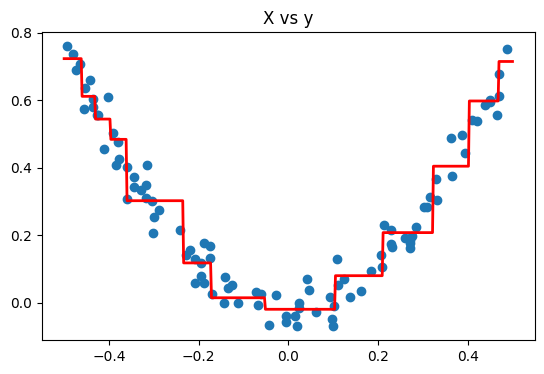

In [28]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth=2,color='red')
plt.scatter(df['X'],df['y'])
plt.title('X vs y')

In [29]:
def gradient_boost(X,y,number,lr,count=1,regs=[],foo=None):

  if number == 0:
    return 
  else:
    # do gradient boosting

    if count > 1:
      y = y - regs[-1].predict(X)
    else:
      foo = y

    tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree_reg.fit(X, y)

    regs.append(tree_reg)

    x1 = np.linspace(-0.5, 0.5, 500)
    y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)

    print(number)
    plt.figure()
    plt.plot(x1, y_pred, linewidth=2)
    plt.plot(X[:, 0], foo,"r.")
    plt.show()

    gradient_boost(X,y,number-1,lr,count+1,regs,foo=foo)

5


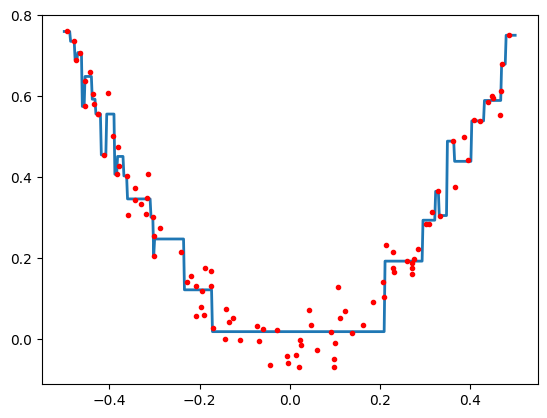

4


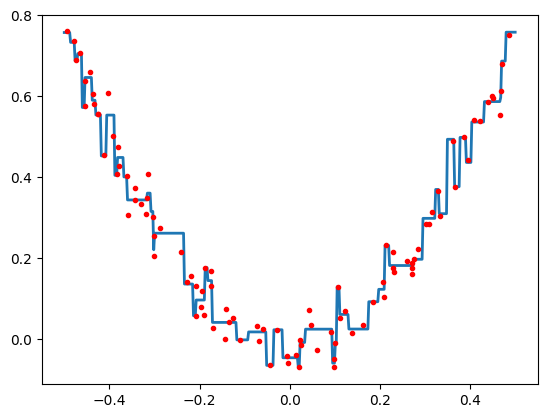

3


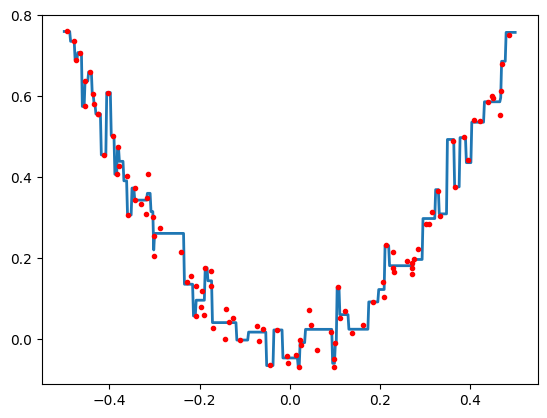

2


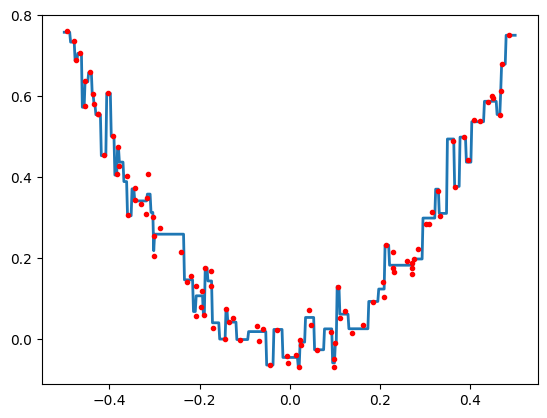

1


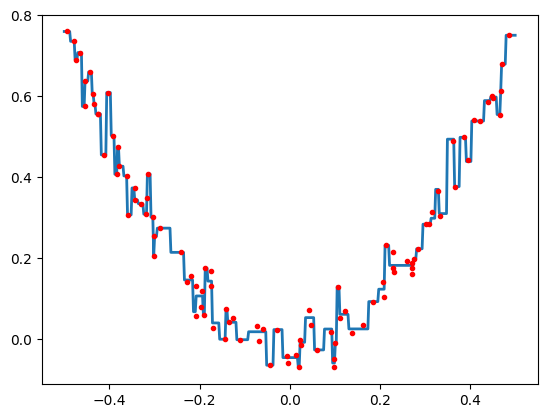

In [30]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)
gradient_boost(X,y,5,lr=1)

# Gradient Boosting for Classification

Gradient Boosting for classification follows the same core algorithmic framework as regression, but with a few critical adjustments to handle discrete classes rather than continuous targets.

---

## 1. The Core Differences from Regression

* **Loss Function:** Instead of Mean Squared Error (MSE), we use **Log Loss** (Binary Cross-Entropy) to evaluate performance.
* **Initial Prediction:** Instead of starting with the *mean* of the target values, we calculate the initial prediction using the **log(odds)**, where the logarithm is base $e$ ($\ln$).
* **Probability Mapping:** To convert log(odds) into a probability, we use the Logistic Sigmoid function:
  $$P(\text{class } 1) = \frac{1}{1 + e^{-\text{log(odds)}}}$$
* **Classification Threshold:** For a final prediction, if the calculated probability is $> 0.5$, we label it as **1**; otherwise, we label it as **0**.

---

## 2. Step-by-Step Algorithm (Binary Classification)

### Step 1: Initialize the model with a constant value
We start by calculating the log(odds) of the positive class in the training set:
$$\text{log(odds)} = \ln\left(\frac{\text{count of 1s}}{\text{count of 0s}}\right)$$
This initial value becomes our starting prediction ($F_0(x)$) for all rows.

### Step 2: Iterative Tree Building (For $m = 1$ to $M$ trees)

#### A. Calculate the Residuals
The formula for the residual (the difference between the actual and predicted value) remains conceptually the same, but it uses the predicted *probability* ($p_i$) from the current model:
$$\text{Residual}_i = y_i - p_i$$
*(Where $y_i$ is the actual label 0 or 1, and $p_i$ is the predicted probability).*

#### B. Build a Decision Tree
We train a regression tree to predict these residuals. However, because we are using Log Loss instead of MSE, we **cannot** simply average the residuals in the leaf nodes. 

#### C. Calculate Leaf Values ($\gamma_{jm}$)
For each leaf $j$ in the new tree, we transformationally scale the residuals. The optimal value for a leaf is calculated as:
$$\gamma_{jm} = \frac{\sum \text{Residual}_i}{\sum p_i (1 - p_i)}$$
*(Summed over all instances $i$ that fall into that specific leaf).*

#### D. Update the Model's Predictions
We update the log(odds) prediction by adding the scaled output of the new tree, controlled by a learning rate ($\nu$):
$$\text{log(odds)}_{new} = \text{log(odds)}_{old} + \left( \nu \times \text{predicted leaf value} \right)$$

---

## 3. Making Final Predictions

1. **Calculate Final Log(Odds):** Pass the data through the initial log(odds) and all $M$ trees.
2. **Convert to Probability:** $$p = \frac{1}{1 + e^{-\text{log(odds)}_{final}}}$$
3. **Apply Threshold:**
   $$\hat{y} = \begin{cases} 1 & \text{if } p > 0.5 \\ 0 & \text{if } p \le 0.5 \end{cases}$$

In [32]:
class CustomGradientBoostingClassifier:
    
    def __init__(self, learning_rate, n_estimators, max_depth=1):
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.trees = []
        
    def fit(self, X, y):
        
        F0 = np.log(y.mean()/(1-y.mean()))  # log-odds values
        self.F0 = np.full(len(y), F0)  # converting to array with the input length
        Fm = self.F0.copy()
        
        for _ in range(self.n_estimators):
            p = np.exp(Fm) / (1 + np.exp(Fm))  # converting back to probabilities
            r = y - p  # residuals
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=0)
            tree.fit(X, r)
            ids = tree.apply(x)  # getting the terminal node IDs

            # looping through the terminal nodes 
            for j in np.unique(ids):
              fltr = ids == j

              # getting gamma using the formula (Σresiduals/Σp(1-p))
              num = r[fltr].sum()
              den = (p[fltr]*(1-p[fltr])).sum()
              gamma = num / den

              # updating the prediction
              Fm[fltr] += self.learning_rate * gamma

              # replacing the prediction value in the tree
              tree.tree_.value[j, 0, 0] = gamma

            self.trees.append(tree)
            
    def predict_proba(self, X):
        
        Fm = self.F0
        
        for i in range(self.n_estimators):
            Fm += self.learning_rate * self.trees[i].predict(X)
            
        return np.exp(Fm) / (1 + np.exp(Fm))  # converting back to probabilities